### Exploratory Analysis of the Dataset

Initial Thoughts after Exploratory Analysis: 

From our exploratory analysis of the data, we know there are around 472 total samples, with 358 of those from metastatic tumor samples. The dataset explores around 15716 genes from A1BG to ZZZ3. There are 80 samples for our specific cancer type in the metadata, which we subset the data to include. The dataset also includes a variety of markers like age at diagnosis, race, gender, histories with other diseases, and tobacco/smoking indicators. These factors can be used to guide and refine our initial proposed project question. In this specific analysis, we subset the data and looked at the following 5 genes: BRAF, NRAS, CDK1, PDXN, TERT. From initial analysis, it appears that the PDXN gene is not found in the dataset. Since there are several other genes associated with the hallmarks we aim to study, we can replace the genes of study as needed. We also looked at the mean and median levels of gene expression for the remaining genes to get an initial understanding of levels in the dataset. They range from 0.67 for TERT to 5.54 for NRAS. Based off initial research. This makes sense because NRAS is more commonly associated with both hallmarks compared to TERT. After some data visualization, it also appears that NRAS expression is much higher than BRAF in SKCM samples. It may be interesting to explore why this is. It is also relatively easy to gather gene expression levels from the dataset, which will be useful during analysis. 

In [6]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#loading the data
data = pd.read_csv(
    r'/Users/priya/Documents/Comp_Bio/GitHub/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r'/Users/priya/Documents/Comp_Bio/GitHub/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(data.head())
print(metadata_df.head())

        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

In [4]:
#exploring the data
print(data.shape)
print(data.info())
print(data.describe())

(15716, 1802)
<class 'pandas.core.frame.DataFrame'>
Index: 15716 entries, A1BG to ZZZ3
Columns: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
dtypes: float64(1802)
memory usage: 216.2+ MB
None
       TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
count                  15716.000000                  15716.000000   
mean                       3.819608                      3.695116   
std                        2.367493                      2.448152   
min                        0.000000                      0.000000   
25%                        1.936472                      1.630385   
50%                        3.906571                      3.775523   
75%                        5.435952                      5.426145   
max                       12.964224                     14.202553   

       TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
count                  15716.000000                  15716.000000   
mean              

In [5]:
#exploring the metadata
print(metadata_df.info())
print(metadata_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   cancer_type                          1802 non-null   object 
 1   bcr_patient_barcode                  1730 non-null   object 
 2   gender                               1730 non-null   object 
 3   race                                 1730 non-null   object 
 4   ethnicity                            1730 non-null   object 
 5   age_at_diagnosis                     1730 non-null   object 
 6   ajcc_pathologic_tumor_stage          1144 non-null   object 
 7   ajcc_nodes_pathologic_pn             1142 non-null   object 
 8   ajcc_metastasis_pathologic_pm        1142 non-null   object 
 9   ajcc_tumor_pathologic_pt             1142 non-null   object 
 10  tumor_status                         1650 non-null

In [14]:
# Subset the data for a specific cancer type
####################################################
cancer_type = 'SKCM'  # Skin Cutaneous Melanoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
print(len(cancer_samples))
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
SKCM_data = data[cancer_samples]


Index(['TCGA-W3-A828-06A-11R-A352-07', 'TCGA-FW-A5DX-01A-11R-A27Q-07',
       'TCGA-D3-A5GU-06A-11R-A27Q-07', 'TCGA-BF-AAP7-01A-11R-A40A-07',
       'TCGA-IH-A3EA-01A-11R-A20F-07', 'TCGA-EE-A3JD-06A-11R-A20F-07',
       'TCGA-EE-A2GH-06A-11R-A18T-07', 'TCGA-BF-A1Q0-01A-21R-A18S-07',
       'TCGA-EE-A2MM-06A-11R-A18S-07', 'TCGA-EE-A3AH-06A-11R-A18S-07',
       'TCGA-ER-A2NB-01A-12R-A18S-07', 'TCGA-FW-A3R5-06A-11R-A239-07',
       'TCGA-DA-A95W-06A-11R-A37K-07', 'TCGA-FR-A7U8-06A-21R-A352-07',
       'TCGA-EE-A2GR-06A-11R-A18S-07', 'TCGA-RP-A694-06A-11R-A311-07',
       'TCGA-D3-A2JK-06A-11R-A18S-07', 'TCGA-EE-A3AC-06A-11R-A18S-07',
       'TCGA-EE-A2GO-06A-11R-A18S-07', 'TCGA-FS-A1ZJ-06A-12R-A18S-07',
       'TCGA-HR-A2OH-06A-11R-A18U-07', 'TCGA-FS-A4F2-06A-11R-A24X-07',
       'TCGA-EE-A3J8-06A-11R-A20F-07', 'TCGA-EB-A41B-01A-11R-A24X-07',
       'TCGA-ER-A42L-06A-11R-A24X-07', 'TCGA-3N-A9WC-06A-11R-A38C-07',
       'TCGA-D3-A2JL-06A-11R-A18S-07', 'TCGA-EE-A2M6-06A-12R-A18S-07',
      

In [7]:
# Subset by index (genes)
####################################################
desired_gene_list = ['BRAF', 'NRAS', 'CDK1', 'PDXN', 'TERT']
gene_list = [gene for gene in desired_gene_list if gene in SKCM_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
SKCM_gene_data = SKCM_data.loc[gene_list]
print(SKCM_gene_data.head())

      TCGA-W3-A828-06A-11R-A352-07  TCGA-FW-A5DX-01A-11R-A27Q-07  \
BRAF                      1.936795                      3.793577   
NRAS                      5.872184                      6.729344   
CDK1                      4.626594                      5.955807   
TERT                      0.540724                      4.206887   

      TCGA-D3-A5GU-06A-11R-A27Q-07  TCGA-BF-AAP7-01A-11R-A40A-07  \
BRAF                      2.595629                      1.553574   
NRAS                      6.365169                      4.519536   
CDK1                      4.616876                      3.335343   
TERT                      2.159369                      1.067104   

      TCGA-IH-A3EA-01A-11R-A20F-07  TCGA-EE-A3JD-06A-11R-A20F-07  \
BRAF                      1.312264                      2.924317   
NRAS                      4.209623                      6.030980   
CDK1                      4.557885                      6.082442   
TERT                      1.632295            

In [8]:
# Basic statistics on the subsetted data
####################################################
print(SKCM_gene_data.describe())
print(SKCM_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(SKCM_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(SKCM_gene_data.median(axis=1))

       TCGA-W3-A828-06A-11R-A352-07  TCGA-FW-A5DX-01A-11R-A27Q-07  \
count                      4.000000                      4.000000   
mean                       3.244074                      5.171404   
std                        2.438265                      1.398948   
min                        0.540724                      3.793577   
25%                        1.587777                      4.103559   
50%                        3.281694                      5.081347   
75%                        4.937992                      6.149191   
max                        5.872184                      6.729344   

       TCGA-D3-A5GU-06A-11R-A27Q-07  TCGA-BF-AAP7-01A-11R-A40A-07  \
count                      4.000000                      4.000000   
mean                       3.934261                      2.618889   
std                        1.942289                      1.598822   
min                        2.159369                      1.067104   
25%                        2.4865

In [9]:
# Explore categorical variables in metadata
####################################################
# groupby allows you to group on a specific column in the dataset,
# and then print out summary stats or counts for other columns within those groups
print(metadata_df.groupby('cancer_type')["gender"].value_counts())

# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())

cancer_type  gender
ACC          FEMALE    48
             MALE      31
BLCA         MALE      66
             FEMALE    10
BRCA         FEMALE    74
             MALE       2
CESC         FEMALE    77
COAD         MALE      41
             FEMALE    31
GBM          MALE      49
             FEMALE    21
HNSC         MALE      58
             FEMALE    19
KICH         MALE      39
             FEMALE    27
KIRC         MALE      51
             FEMALE    27
KIRP         MALE      49
             FEMALE    24
LAML         MALE      45
             FEMALE    35
LGG          MALE      40
             FEMALE    30
LIHC         MALE      56
             FEMALE    21
LUAD         FEMALE    39
             MALE      35
LUSC         MALE      54
             FEMALE    24
OV           FEMALE    77
PRAD         MALE      78
READ         MALE      44
             FEMALE    36
SKCM         MALE      50
             FEMALE    29
STAD         MALE      50
             FEMALE    30
THCA         FEMAL

In [10]:
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
SKCM_metadata = metadata_df.loc[cancer_samples]
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True)
print(SKCM_merged.head())

                                  BRAF      NRAS      CDK1      TERT  \
TCGA-W3-A828-06A-11R-A352-07  1.936795  5.872184  4.626594  0.540724   
TCGA-FW-A5DX-01A-11R-A27Q-07  3.793577  6.729344  5.955807  4.206887   
TCGA-D3-A5GU-06A-11R-A27Q-07  2.595629  6.365169  4.616876  2.159369   
TCGA-BF-AAP7-01A-11R-A40A-07  1.553574  4.519536  3.335343  1.067104   
TCGA-IH-A3EA-01A-11R-A20F-07  1.312264  4.209623  4.557885  1.632295   

                             cancer_type bcr_patient_barcode  gender   race  \
TCGA-W3-A828-06A-11R-A352-07        SKCM        TCGA-W3-A828    MALE  WHITE   
TCGA-FW-A5DX-01A-11R-A27Q-07        SKCM        TCGA-FW-A5DX    MALE  WHITE   
TCGA-D3-A5GU-06A-11R-A27Q-07        SKCM        TCGA-D3-A5GU    MALE  WHITE   
TCGA-BF-AAP7-01A-11R-A40A-07        SKCM        TCGA-BF-AAP7  FEMALE  WHITE   
TCGA-IH-A3EA-01A-11R-A20F-07        SKCM        TCGA-IH-A3EA    MALE  WHITE   

                                           ethnicity  age_at_diagnosis  ...  \
TCGA-W3-A828-

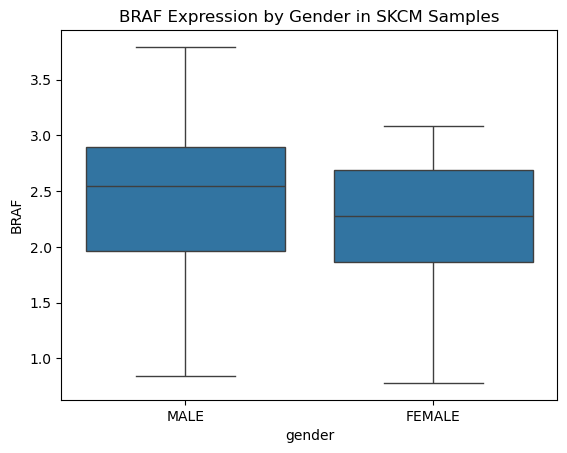

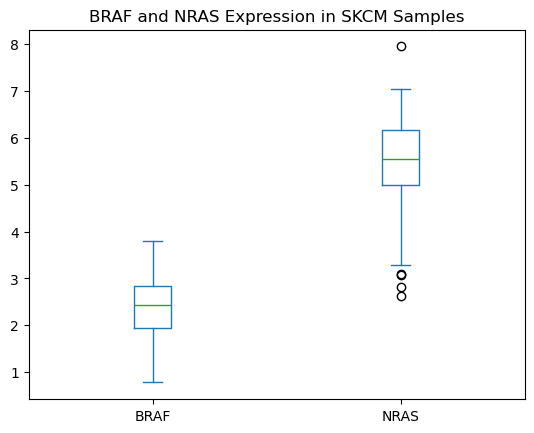

In [13]:
# Plotting
####################################################
# Boxplot of BRAF expression in SKCM samples using SEABORN
# Works really well with pandas dataframes, because most methods allow you to pass in a dataframe directly
sns.boxplot(data=SKCM_merged, x="gender", y='BRAF')
plt.title("BRAF Expression by Gender in SKCM Samples")
plt.show()

# Boxplot of NRAS and BRAF expression in SKCM samples using PANDAS directly
SKCM_merged[['BRAF', 'NRAS']].plot.box()
plt.title("BRAF and NRAS Expression in SKCM Samples")
plt.show()

## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

### Principal Component Analysis 

We first conducted principal component analysis to explore our dataset. We aimed to implement dimensional reduction techniques to reduce the number of features in the large dataset, but still see the big picture of trends occurring to refine our project goals and questions and guide our analysis. 

In [2]:
#import the necessary libraries for analysis
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
#read in the data again, but this time we will be using it for dimensionality reduction, so we will subset by cancer type and genes of interest in the same step
data = pd.read_csv(
    r'/Users/priya/Documents/Comp_Bio/GitHub/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r'/Users/priya/Documents/Comp_Bio/GitHub/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
#subset the data for cancer type and genes of interest 
cancer_type = 'SKCM'  # Skin Cutaneous Melanoma
# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
SKCM_data = data[cancer_samples]
#this list of genes is from both hallmarks we are concerned with, it has been cleaned to remove genes that are not in the dataset and any duplicates between the hallmarks 
desired_gene_list = [
    "ANGPTL3", "CXCR4", "LAMA4", "EFNB1", "MAP3K8", "RHOA", "TBL1XR1", "WNT5B",
    "LAMA5", "ITGA2B", "SDC1", "NGF", "NFKB2", "NTNG1", "HCK", "PDPK1", "CDH5",
    "WNT10A", "MAPKAPK2", "PIP5K1C", "CDC42BPA", "ABL2", "RAB11A", "TGFA", "ARRB1",
    "ITGA5", "PLCG1", "RASA1", "RRAS", "ENG", "CLDN15", "PIK3CD", "LAMB2", "CNR1",
    "WAS", "CLDN20", "FPR2", "PARD3", "SDC3", "ELMO2", "GP1BA", "FYN", "LIMK1",
    "PXN", "MAP3K2", "XIAP", "ERBB3", "CD6", "NRXN2", "PRKACB", "GFRA1", "TNF",
    "PRKACA", "S1PR1", "ITGB1", "PLXND1", "DUSP1", "BAMBI", "COL6A3", "NTF3",
    "MMP7", "CDC42", "RAPGEF1", "PTEN", "FGF10", "CD34", "FLNA", "ALCAM", "CRKL",
    "LAMC1", "AKT1", "IRS2", "SMAD2", "CAV1", "MADCAM1", "BMP7", "ACTR2", "CD44",
    "CLDN3", "TLR2", "ID1", "GNG2", "LAMB1", "GNA12", "ITGAL", "EFNA3", "NCKAP1",
    "SPHK1", "WNT9A", "SSX2IP", "DPP4", "NLGN2", "CTNNA1", "PRKCD", "PLCB3",
    "EPHB2", "CASP8", "TRIP6", "FGFR1", "EFNA1", "GNB5", "MYH9", "EPHB1", "ITGB2",
    "CBL", "CNTNAP1", "FAT1", "NRXN1", "ARHGEF7", "CD99", "NTRK2", "JUP", "NCAM1",
    "CDH4", "F11R", "RB1", "COL1A1", "EPHA2", "FN1", "IGF1R", "MYLPF", "PARVA",
    "EPHA3", "PIK3CB", "SNAI1", "WNT7A", "WNT3A", "NFASC", "SELPLG", "DDX5",
    "ITGAM", "GNAO1", "TJP1", "PARVG", "EPHA4", "ACTN1", "MYC", "CXCR3", "MAPK7",
    "ACVR1", "ARF6", "RAB5A", "ICAM3", "CD22", "EXOC2", "CLDN1", "ACVR2B",
    "CLDN10", "RPS6KB1", "CLDN19", "NTRK1", "PIK3CA", "CD36", "MAPK8IP3", "LPAR1",
    "SIGLEC1", "GPC4", "LAMB3", "GAB1", "NCK2", "MAP4K1", "WNT2", "WASF2", "CD86",
    "CADM3", "FER", "MAPK14", "PTK2", "CTTN", "STAT5B", "DVL1", "CADM1", "TLR4",
    "MTOR", "ARF4", "F2RL3", "CXCL12", "ARHGDIA", "WASL", "CLDN9", "PLCB1",
    "NRCAM", "PLD2", "LCP2", "DOCK2", "PRKCE", "KDR", "PDGFB", "MMP2", "COMP",
    "MSN", "FZD2", "PRKCG", "SYMPK", "RAF1", "JUN", "KIT", "EGFR", "VAV2", "SMPD1",
    "MAP3K7", "JAM2", "APC", "CASP3", "ARRB2", "NRG2", "ERBB2", "ACTN4", "FGF1",
    "CD63", "SOS1", "GNB1", "PRKCQ", "GPC3", "HGF", "MAP3K3", "CD47", "MAP2K6",
    "NLGN3", "CLDN16", "IBSP", "CD28", "SHC2", "NFATC2", "PAK2", "PVRL2", "EPHA1",
    "ITGB7", "FLT1", "TLN1", "ARHGEF1", "MAP4K3", "PPP3R1", "RALA", "ERBB4",
    "MAPRE1", "TAOK2", "MAPKAPK5", "SMAD3", "MMP3", "NEO1", "SIPA1", "ITGAE",
    "BDNF", "CLDN18", "RAP1B", "PRKG1", "ITGB5", "GNAI3", "PFN1", "LPAR3", "SRC",
    "CASK", "PTPRJ", "WNT5A", "ZAP70", "CD2AP", "IKBKB", "PAK1", "CLDN23", "NTRK3",
    "DRD2", "PARD6A", "MAPK12", "PKN2", "ITGA7", "RAC2", "PPARD", "ELMO1", "ITGA8",
    "FGFR4", "THBS1", "KITLG", "BRAF", "RND2", "PTPRF", "THBS2", "VAV3", "ITGA4",
    "RASGRF1", "EZR", "LAMA2", "FGFR2", "TNXB", "EFNB2", "PTK6", "CDH2", "EGF",
    "NRG1", "ACVRL1", "RND3", "VASP", "ESR1", "PLEKHA7", "PRICKLE1", "RAC1", "NF1",
    "EPHB4", "GRB2", "BAIAP2", "RRAS2", "WNT11", "WASF1", "IL1A", "EREG",
    "ARHGAP35", "PRKCZ", "FLT4", "RALGDS", "PTPN6", "COL6A6", "P2RY1", "HPSE",
    "LPAR2", "MYL9", "PTPRM", "YES1", "SHROOM2", "NGFR", "ETS1", "ACTB", "PTPN1",
    "NCK1", "ARPC5", "ARAP3", "MDK", "THBS3", "ITGA3", "PTPN11", "CLDN8", "PTK2B",
    "MAP2K2", "VTN", "NODAL", "ITGA9", "CLDN4", "PIP5K1A", "GPC2", "TGFBR2",
    "MAPKAPK3", "BCL2L1", "EPHB3", "ABI2", "MAX", "APC2", "CLDN11", "PRKCA",
    "SELL", "CCND1", "SDC4", "WASF3", "FAT4", "TNC", "BMPR2", "MAP2K4", "PDGFA",
    "MAP3K12", "RHOC", "BCL2", "PIK3R1", "SPN", "BMPR1A", "CDKN1A", "TLN2",
    "LAMC3", "ABL1", "PTPRC", "THY1", "EXOC3", "VCAN", "SHC3", "PVR", "GNAI1",
    "TGFB1", "ITGA6", "CASP9", "PRKD2", "CFL1", "ITGB4", "AKT2", "ITGA1",
    "PDGFRA", "NFKB1", "MAP2K3", "PRKCH", "HSPB1", "RET", "CRK", "CDK1", "MAPK3",
    "DOCK1", "PDGFRB", "ESAM", "DVL3", "PRKCI", "LAMA3", "VAV1", "TNFRSF1A",
    "GRIN2A", "FAS", "IGF1", "MMP14", "ROCK2", "COL6A1", "ACVR2A", "VWF", "JAM3",
    "PLCB2", "PLAU", "TRAF6", "DAAM1", "WNT4", "L1CAM", "SMAD4", "LAT", "ITGAV",
    "FES", "CDH1", "CD2", "DICER1", "SPP1", "LAMC2", "ZYX", "CLDN6", "CLDN2",
    "CCL11", "BMP2", "MMP9", "MAPK8IP2", "IQGAP1", "PSEN1", "HRAS", "PLAUR",
    "UNC5C", "NLGN4X", "ANGPT2", "TIAM1", "WNT3", "WNT7B", "LEF1", "SNAI2",
    "NTNG2", "KSR1", "MAGI1", "MAP4K4", "FARP2", "MAG", "JUND", "ITGA2", "TGFB2",
    "STAT3", "CREBBP", "NEGR1", "DRD1", "F2R", "PPP2R2A", "CDKN1B", "MYLK",
    "HLA-DRB1", "CDK5", "NOG", "ITGB8", "HIF1A", "RAP1A", "LAMA1", "CAMK2G",
    "GNAI2", "OMG", "TGFBR1", "RDX", "CAPN2", "GSK3B", "CTNNA2", "CD4", "WNT2B",
    "FGF2", "TCF7L2", "NOS3", "ILK", "MAP3K4", "CNTNAP2", "CLDN14", "NRAS",
    "SELP", "GJA1", "VEGFA", "RELN", "PPP3CA", "CDH11", "CD226", "KRAS", "GNAS",
    "WNT10B", "ROCK1", "PARVB", "EFNA5", "AJUBA", "FPR1", "EFNA2", "NRXN3", "FAP",
    "RHOB", "MYH10", "MAPK1", "MAPK8", "FGB", "HLA-DRA", "GPC1", "CDH15", "PLD1",
    "DAB1", "CNTN2", "CTNND1", "MET", "TP53", "LIMA1", "ITGA11", "SDC2", "NLGN1",
    "ANGPT1", "FRS2", "RIN1", "DNM2", "PIK3CG", "MAP3K11", "MAPK13", "DVL2",
    "SELE", "CLDN7", "ENAH", "DAXX", "SHC1", "NCAM2", "THBS4", "VCAM1", "MAPK10",
    "BSG", "ACTR3", "COL4A6", "ITGB3", "PAK4", "AKT3", "MAPK9", "DDR2", "PTPN13",
    "DIAPH1", "PPP2R1A", "PTPRB", "RALB", "PAFAH1B1", "BRK1", "MAP2K1", "ACTN2",
    "ICAM2", "CSF1", "MAP4K2", "COL1A2", "PPP2CA", "MAP3K1", "BMX", "CTNNB1",
    "TEK", "ABI1", "MAP2K7", "ARHGAP5", "GAB2", "FASLG", "BIRC3", "EXOC4", "BCAR1",
    "ITGA10", "ITGB6", "COL4A3", "CD80", "VCL", "MFGE8", "CSF3R", "TRAF2",
    "SLC9A1", "MAPK11", "PRKCB", "GNA11", "ICAM1", "CLDN5", "CBLB", "TGFB3",
    "WNT6", "NOTCH2", "MAP3K5", "COL6A2", "MAP2K5", "CNTN1", "CDH3", "HBEGF",
    "CYFIP2", "GNAQ", "STAT1", "RIPK1", "CDC25B", "INPP5D", "ACER2", "PPARG",
    "PPP1R12A", "GLI2", "CSNK1A1", "CACNA1I", "RPTOR", "BMP4", "FLT3", "CD40LG",
    "CSNK1D", "IL17D", "PPP1R12B", "DGKI", "PTCH1", "SMAD1", "SFN", "RASAL2",
    "CSF3", "PPP2R5E", "SERPINE1", "HDAC1", "MPL", "YWHAB", "TSLP", "BIRC2",
    "NSMAF", "CSNK1G2", "LPAR6", "RALBP1", "S1PR2", "PKN1", "STK3", "SH2D2A",
    "OSM", "NPM1", "AR", "GNB2", "GNG10", "FGF17", "SFRP5", "HDAC2", "CCND3",
    "PLCD3", "RASSF1", "RPS6KB2", "EPO", "SOCS3", "PHLPP2", "IRS1", "PTPN5",
    "IL6R", "BIRC5", "SLC44A4", "PGF", "SUZ12", "STK11", "ATF6B", "BCL2L11",
    "CSF2RB", "IHH", "DLG1", "IL2RG", "PLCD4", "SDCBP", "PRKAA1", "CSNK1G3", "IL7",
    "YWHAE", "MRAS", "PPP3CB", "RASGRP1", "EZH2", "RASAL1", "IL6ST", "HTR7", "GLI1",
    "LRP5", "SUFU", "ASAH1", "IL7R", "SHOC2", "JAK1", "GNG13", "GNB3", "RASSF6",
    "SGMS1", "YWHAG", "IL2RB", "CREB1", "NTF4", "RASA2", "MED1", "CBLC", "RHEB",
    "RASAL3", "SYK", "STAM2", "PLA2G1B", "FOS", "ADORA3", "FGF11", "TRAF1",
    "FGF13", "RIPK2", "HCLS1", "DLG4", "PPP1R12C", "HSP90AA1", "BRCA1", "FZD3",
    "FZD10", "VEGFB", "GATA3", "BDKRB2", "IL1R1", "CALML5", "SPDYA", "IL1B", "ID4",
    "RGL1", "CHRM1", "PLCE1", "LYN", "PIK3AP1", "ACVR1B", "CCNB1", "IGF2", "NF2",
    "FGF22", "MLST8", "RAPGEF2", "SPHK2", "RPS6KA6", "NCOA2", "CDK4", "JAK2",
    "TYK2", "GNG11", "IL10", "ANK3", "ARAF", "OSMR", "ADIPOQ", "SOCS1", "GNGT1",
    "SMPD3", "YAP1", "CDK2", "SMAD5", "FOSL1", "FZD7", "DOK2", "SYNGAP1",
    "CSNK1A1L", "IFNG", "CXCL11", "MAP3K13", "MS4A2", "PPP2R5B", "GATA2", "CDK6",
    "SAV1", "RACGAP1", "CXCL9", "ARHGAP26", "FGF7", "LPAR4", "CCND2", "NBL1",
    "STAM", "LIFR", "GNGT2", "GNA13", "CSNK2A1", "IL4R", "IL2RA", "GNB4", "IL10RB",
    "LCK", "IL27", "PTPRR", "RASGRP2", "IL20", "YWHAZ", "FZD5", "ITPR2", "ITPR1",
    "GNAZ", "NDRG1", "RGL2", "PRLR", "ATM", "CD79A", "STAT2", "WIF1", "CSNK1E",
    "PPP2R5A", "LPAR5", "AREG", "PTPN2", "NRG4", "FOXO1", "EP300", "CSNK1G1",
    "STAT4", "ELK1", "LIF", "CTF1", "TEAD1", "CALR", "SHC4", "CISH", "DGKD",
    "KSR2", "DGKZ", "GNG5", "NOTCH1", "MYD88", "KAT2B", "BMP6", "PLCG2",
    "MAPK8IP1", "HHIP", "THPO", "S1PR3", "RPS6KA3", "ADORA1", "DGKA", "TCL1A",
    "IL24", "CSF1R", "BARD1", "GNG12", "ALK", "CHEK1", "BMP5", "ACSL4", "CAMK2B",
    "ANK2", "TP63", "VEGFC", "IL12RB1", "DGKE", "TRADD", "PIK3R2", "YWHAH",
    "IL11RA", "MDM2", "STMN1", "HPSE2", "MAP3K6", "ROS1", "RASSF5", "IL13RA1",
    "CHN2", "SH3BP5", "CNTFR", "FGF19", "PKN3", "CXCL13", "CRADD", "FGF12",
    "IL12RB2", "FZD4", "FLNB", "MCL1", "CSF2RA", "IL12A", "CSF2", "CSNK2B",
    "SOCS5", "PAG1", "NR4A1", "GNG3", "PIM1", "PRKAA2", "ANK1", "EPOR", "SMO",
    "FADD", "SMARCA2", "DGKQ", "PHLPP1", "DGKH", "ZFYVE16", "RASA4", "ELK4",
    "JAK3", "IL11", "BEX1", "IFNGR1", "IL6", "LRP6", "SFRP2", "S1PR4", "IL27RA",
    "PDGFC", "RASA3", "CREB3L2", "GNG4", "PLCB4", "STK4", "FZD6", "DGKG", "WWTR1",
    "PPP2R5C", "FGF9", "GNG8", "SHH", "PLCD1", "RPS6KA1", "PRC1", "EPAS1", "MED12",
    "BTC", "CACNA1D", "CXCL10", "IL15", "GSK3A", "STAT6", "GNG7", "BTRC", "PTGS2",
    "FZD9", "NCOR1", "FGF14", "RPS6KA2", "TP53BP2", "STAT5A", "YWHAQ", "PDGFD",
    "INSR", "VLDLR", "FZD1", "S1PR5", "SFRP1", "FGF18", "PPP2R5D", "NLK", "FGF20",
    "FGFR3", "CCNE1", "RELA", "IL23A", "INHBA", "LEFTY2", "FZD8", "RPS6"
]
gene_list = [gene for gene in desired_gene_list if gene in SKCM_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")
SKCM_gene_data = SKCM_data.loc[gene_list]
# %%
#need merged data for coloring by something in visualizations, otherwise just use the gene data
SKCM_metadata = metadata_df.loc[cancer_samples]
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True)


In [7]:
#scale the data for dimensionality reduction, only using the gene expression columns, not the metadata columns
X = SKCM_merged[gene_list] # gene expression only

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scree Plot

Since the PCA can vary based on the number of components included, we wanted to justify and choose of number of components that will accurately capture the variance in the dataset. Thus, we used a scree plot to analyze the variance. 

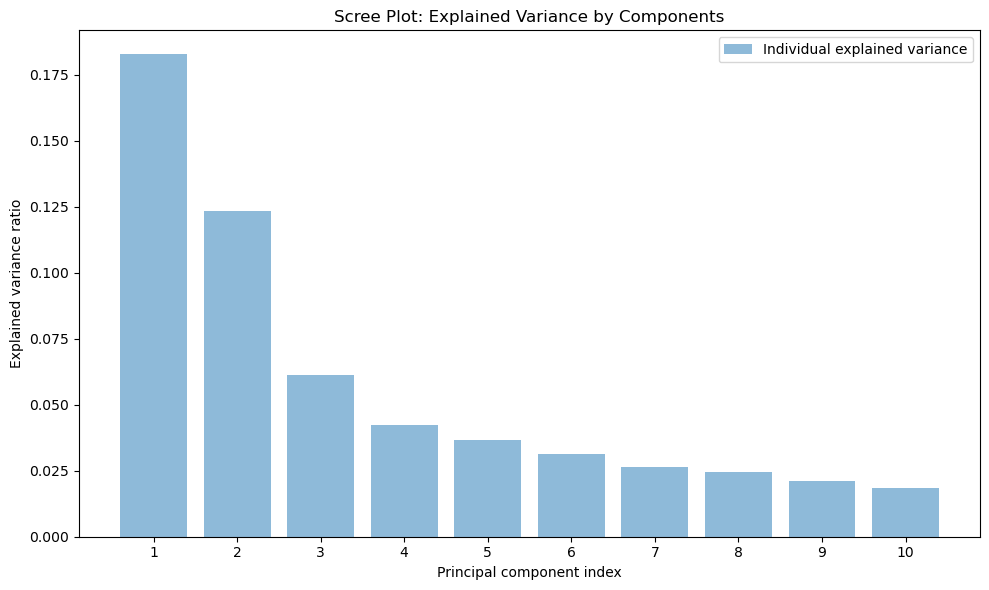

In [9]:
pca_full = PCA(n_components=10) 
pca_full.fit(X_scaled)

# 2. Get the explained variance ratio
exp_var_pca = pca_full.explained_variance_ratio_

# 3. Cumulative sum of explained variance
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

#create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
        label='Individual explained variance')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Explained Variance by Components')
plt.xticks(range(1, len(exp_var_pca) + 1))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

From the scree plot, we can see that majority of the variance is captured by the first teo principal component indexes. Thus, we will use 2 components in our PCA analysis. 

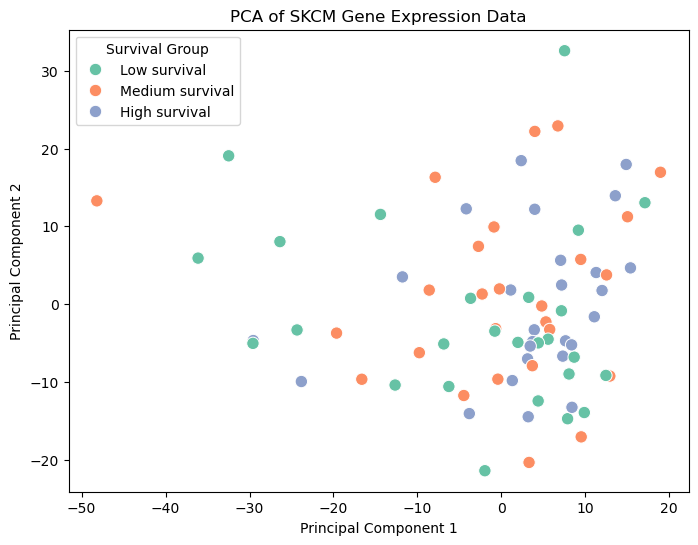

In [10]:
#principal component analysis and coloring by survival group (we will use overall survival time, which is a continuous variable, and convert it to a categorical variable for coloring)
SKCM_merged['OS_group'] = pd.qcut(
SKCM_merged['OS.time'],
q=3,
labels=["Low survival", "Medium survival", "High survival"]
)

y = SKCM_merged['OS_group'] #for coloring 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
x=X_pca[:, 0],
y=X_pca[:, 1],
hue=y,
palette="Set2",
s=80
)

plt.title("PCA of SKCM Gene Expression Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Survival Group")
plt.show()


From this initial PCA, we can see there are not any clear clusters or data with strong correlation. However, there is one clump of data points near the bottom right quadrant, suggesting that a large portion of the dataset have similar gene expression profiles regardless of survival outcome. There also appear to be outliers on the far left towards the top that differ significantly from the main group. From this initial analysis, we can understand that gene expression does not appear to be a predictor of survival outcome from PC1 and PC2. We may benefit from recoloring the same plot to see if there are other factors that would lead to clusters. 

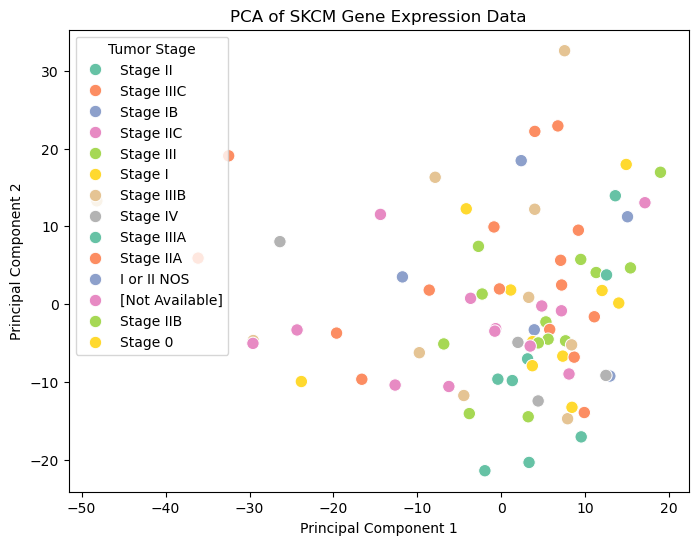

In [17]:
y = SKCM_merged['ajcc_pathologic_tumor_stage'] #for coloring 

#pca = PCA(n_components=2)
#X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
x=X_pca[:, 0],
y=X_pca[:, 1],
hue=y,
palette="Set2",
s=80
)

plt.title("PCA of SKCM Gene Expression Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Tumor Stage")
plt.show()

Based on this PCA analysis and coloring by the stage of the cancer, we seem to get similar results to before where the gene expression profiles do not significantly affect the stage of cancer. Thus, as a next step we analyzed the loading scores for PC1 to determine which genes had the largest influence. 

In [24]:
#Get the loadings for PC1
loadings = pd.Series(pca.components_[0], index=gene_list)
# Sort by absolute value to find the most influential genes
top_genes = loadings.abs().sort_values(ascending=False).head(20)
top_loadings = loadings.loc[top_genes.index]
print("Top 10 Genes influencing PC1:")
print(top_loadings.head(10))

Top 10 Genes influencing PC1:
ACTR2       0.071408
PPP1R12A    0.070648
ROCK1       0.068719
CREB1       0.068311
XIAP        0.068032
MAP3K2      0.067335
SOCS5       0.067260
STAM2       0.066581
PRKAA1      0.066462
MAP3K7      0.066142
dtype: float64


The top genes listed are heavily involved in cell signaling, structural remodeling, and survival pathways. The top genes are close in magnitude, likely meaning that they are co-expressed, which would also explain the large clump of data points on the right side of the PCA plot. In future analysis, we will keep these genes in mind to understand their role in the progression of Melanoma. 

### K-means Clustering

We implemented this method to identify groups of commonalities in the PCA plot based on feature similarity. 

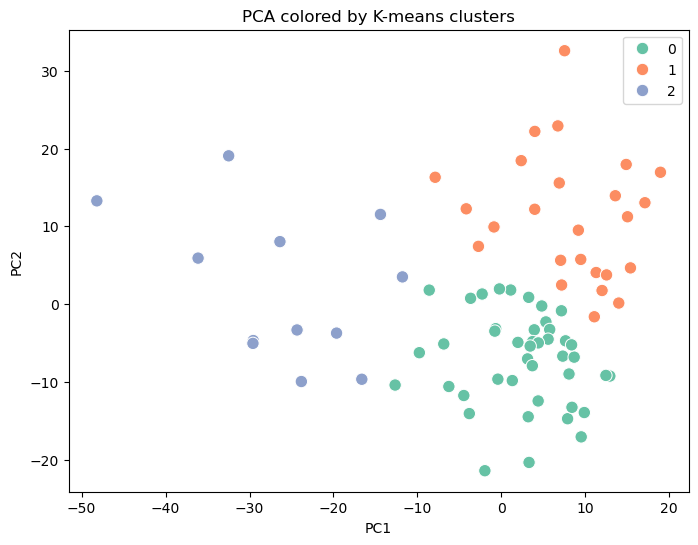

In [21]:
#Using K-means to cluster the data in PCA space
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
x=X_pca[:,0],
y=X_pca[:,1],
hue=clusters,
palette="Set2",
s=80
)

plt.title("PCA colored by K-means clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


The blue cluster appears to be composed of outliers. The top genes from the loading score analysis for PC1 are less expressed in this group. The green group represents the most common gene expression profile. Since the orange group is more in line with PC2, whatever genes drive PC2 are more active here. 

In [25]:
#Get the loadings for PC2
loadings = pd.Series(pca.components_[1], index=gene_list)
# Sort by absolute value to find the most influential genes
top_genes = loadings.abs().sort_values(ascending=False).head(20)
top_loadings = loadings.loc[top_genes.index]
print("Top 10 Genes influencing PC2:")
print(top_loadings.head(10))

Top 10 Genes influencing PC2:
WAS       0.082070
PARVG     0.081840
PTPN6     0.081309
SELPLG    0.080019
GATA3     0.079244
S1PR4     0.079204
RASAL3    0.078713
RASSF5    0.078470
GNGT2     0.078456
RAC2      0.077748
dtype: float64


The genes heavily influecing PC2 are heavily involved in immune expression and activity. Thus, we would expect these patients to have higher survival outcome. 

### Revised Project Goal 

Based on our initial PCA and clustering analysis, we identified some key insights into our datasight. Upon first look, it did not appear the gene expression profiles affected survival outcome and the stage of cancer. However, upon further clustering analysis, we noticed three groups of varying gene profiles. One aligned with PC1 had more expression of genes involved in cell signaling and structural remodeling. The second cluster aligned with PC2, had a more interesting gene expression profile with genes heavily involved in immune expression and activity. This may worth noting and exploring more in depth. 

Refined Question: How do gene expression profiles influence survival outcome in Melanoma. 

In our initial analysis, we broke up survival outcome into 3 buckets. Based on the initial analysis, we believe we will be able to gain more insights by treating the time as a continuous variable. Thus, we plan to implement a regression model. 

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*